In [ ]:
# Check GPU usage
!nvidia-smi

Sun Feb  1 21:31:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   68C    P0             32W /   72W |    8753MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Check memory
import psutil
print(f"Memory: {psutil.virtual_memory().percent}%")

Memory: 10.4%


In [ ]:
# Check TPU status
import jax
print(jax.devices())

[CudaDevice(id=0)]


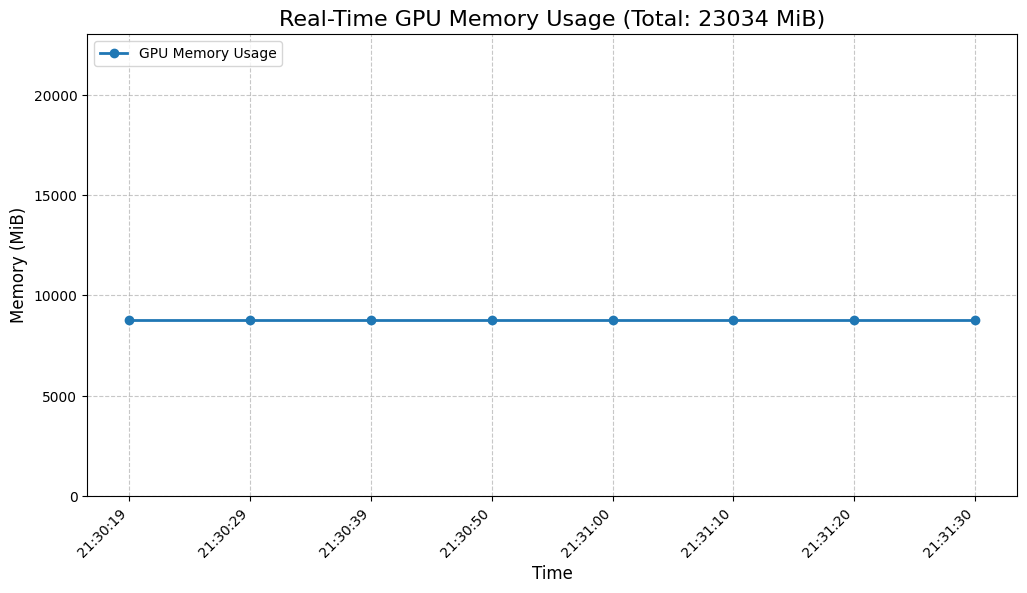

Monitoring stopped manually.
Monitoring finished.


In [3]:
import subprocess
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
import datetime

# --- Configuration ---
DURATION_MINUTES = 10
UPDATE_INTERVAL_SECONDS = 10
# ---------------------

def get_gpu_memory_info():
    """Queries nvidia-smi for used and total GPU memory (in MiB)."""
    try:
        # Get used memory
        used = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,nounits,noheader'],
            encoding='utf-8'
        )
        # Get total memory
        total = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,nounits,noheader'],
            encoding='utf-8'
        )
        return int(used.strip()), int(total.strip())
    except Exception:
        # Fallback if no GPU found
        return 0, 10000

timestamps = []
memory_usage = []
start_time = time.time()
end_time = start_time + (DURATION_MINUTES * 60)

# Fetch total memory once to set the graph limit
_, total_memory = get_gpu_memory_info()

print(f"Starting GPU monitoring at {datetime.datetime.now().strftime('%H:%M:%S')} for {DURATION_MINUTES} minutes...")
print(f"Total GPU Memory detected: {total_memory} MiB")

try:
    while time.time() < end_time:
        current_str = datetime.datetime.now().strftime("%H:%M:%S")
        used_mem, _ = get_gpu_memory_info()

        timestamps.append(current_str)
        memory_usage.append(used_mem)

        # Keep a rolling window
        if len(timestamps) > 30:
            timestamps.pop(0)
            memory_usage.pop(0)

        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(timestamps, memory_usage, color='tab:blue', marker='o', linestyle='-', linewidth=2, label='GPU Memory Usage')
        
        # Set y-axis to range from 0 to Total Memory
        plt.ylim(0, total_memory)
        
        plt.title(f"Real-Time GPU Memory Usage (Total: {total_memory} MiB)", fontsize=16)
        plt.ylabel("Memory (MiB)", fontsize=12)
        plt.xlabel("Time", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='upper left')
        
        clear_output(wait=True)
        plt.show()

        time.sleep(UPDATE_INTERVAL_SECONDS)

except KeyboardInterrupt:
    print("Monitoring stopped manually.")

print("Monitoring finished.")